In [1]:
#!/usr/bin/env julia

include(joinpath(@__DIR__, "MonteCarloMF.jl"))

using DifferentialEquations
using JLD2
using Printf
using Random
using Statistics

if !haskey(ENV, "MPLCONFIGDIR")
    mpl_config_dir = joinpath(tempdir(), "matplotlib")
    mkpath(mpl_config_dir)
    ENV["MPLCONFIGDIR"] = mpl_config_dir
end
if !haskey(ENV, "MPLBACKEND")
    ENV["MPLBACKEND"] = "Agg"
end

using PyPlot

const ROOT_DIR = normpath(joinpath(@__DIR__, ".."))

state_observable(S, M, N, Gamma, xi) = (S = S, M = M)

function dicke_Gn(S, M, n::Int)
    n >= 1 || error("correlation order n must be >= 1")

    out = 1.0
    for j in 0:(n - 1)
        out *= Float64(S + M - j) * Float64(S - M + 1 + j)
    end
    return out
end

function safe_divide(num::AbstractVector, den::AbstractVector; eps = 1e-14)
    out = Vector{Float64}(undef, length(num))
    for i in eachindex(num, den)
        out[i] = abs(den[i]) > eps ? num[i] / den[i] : NaN
    end
    return out
end

function normalize_moments(moment_matrix, orders)
    idx1 = findfirst(==(1), orders)
    idx1 === nothing && error("orders must contain n = 1")

    G1 = moment_matrix[:, idx1]
    normalized = fill(NaN, size(moment_matrix))
    for (j, n) in enumerate(orders)
        normalized[:, j] = safe_divide(moment_matrix[:, j], G1 .^ n)
    end
    return normalized
end

function simulate_full_jump_reference(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_grid,
    orders,
    n_traj::Int;
    sizehint::Int = 0,
    store_histories::Bool = true,
)
    sums = zeros(Float64, length(t_grid), length(orders))
    histories = Any[]
    store_histories && sizehint!(histories, n_traj)

    for traj in 1:n_traj
        ts, states = run_trajectory(
            N, Gamma, xi, gamma, Float64(last(t_grid)), state_observable;
            sizehint = sizehint,
        )

        if store_histories
            push!(
                histories,
                (
                    t = collect(ts),
                    S = [state.S for state in states],
                    M = [state.M for state in states],
                ),
            )
        end

        idx = 1
        for (k, t) in enumerate(t_grid)
            while idx < length(ts) && ts[idx + 1] <= t
                idx += 1
            end

            S = states[idx].S
            M = states[idx].M
            for (j, n) in enumerate(orders)
                sums[k, j] += dicke_Gn(S, M, n)
            end
        end

        if traj % max(1, n_traj ÷ 10) == 0
            @printf("  full MC: %d/%d trajectories\n", traj, n_traj)
        end
    end

    moments = sums ./ n_traj
    return (
        G = moments,
        g = normalize_moments(moments, orders),
        histories = histories,
    )
end

function run_seed_trajectory(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    α::Float64;
    M0::Int = N ÷ 2,
    S0::Int = N ÷ 2,
    store_history::Bool = true,
)
    S::Int = S0
    M::Int = M0
    t = 0.0
    threshold = Float64(N)^α
    G1 = dicke_Gn(S, M, 1)

    ts = Float64[t]
    Ss = Int[S]
    Ms = Int[M]

    nminus = S - M
    if nminus >= threshold
        return (reached = true, t = t, S = S, M = M, G1 = G1,
                ts = ts, Ss = Ss, Ms = Ms)
    end

    while t < t_max
        nminus = S - M

        r_dec = Gamma * A_JM_minus2(S, M) + gamma * P_JM_minus_02(S, M, N)
        r_up = xi * P_JM_z_plus2(S, M, N)
        r_down = xi * P_JM_z_minus2(S, M, N)
        r_dec_down = gamma * P_JM_minus_minus2(S, M, N)
        r_dec_up = gamma * P_JM_minus_plus2(S, M, N)

        r_total = r_dec + r_up + r_down + r_dec_up + r_dec_down
        if r_total <= 1e-10
            return (reached = false, t = Inf, S = S, M = M, G1 = G1,
                    ts = ts, Ss = Ss, Ms = Ms)
        end

        tau = -log(rand()) / r_total
        t_next = t + tau

        r_val = rand() * r_total
        if r_val < r_dec
            M -= 1
        elseif r_val < r_dec + r_up
            S += 1
        elseif r_val < r_dec + r_up + r_down
            S -= 1
        elseif r_val < r_dec + r_up + r_down + r_dec_up
            S += 1
            M -= 1
        else
            S -= 1
            M -= 1
        end

        t = t_next
        G1 = dicke_Gn(S, M, 1)

        if store_history
            push!(ts, t)
            push!(Ss, S)
            push!(Ms, M)
        end

        nminus = S - M
        if t <= t_max && nminus >= threshold
            return (reached = true, t = t, S = S, M = M, G1 = G1,
                    ts = ts, Ss = Ss, Ms = Ms)
        end
    end

    return (reached = false, t = Inf, S = S, M = M, G1 = G1,
            ts = ts, Ss = Ss, Ms = Ms)
end

function simulate_seed_times(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    α::Float64,
    n_seed::Int,
)
    seeds = Vector{Any}(undef, n_seed)
    for traj in 1:n_seed
        seeds[traj] = run_seed_trajectory(N, Gamma, xi, gamma, t_max, α)
        if traj % max(1, n_seed ÷ 10) == 0
            @printf("  seed MC α = %.4g: %d/%d trajectories\n", α, traj, n_seed)
        end
    end
    return seeds
end

function solve_seed_meanfield(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_max::Float64,
    I0::Float64,
    m0::Float64;
    reltol = 1e-9,
    abstol = 1e-11,
)
    p = [Gamma, xi, N, gamma]
    prob = ODEProblem(meanfield_reduced!, [I0, m0], (0.0, t_max), p)
    return solve(
        prob,
        AutoTsit5(Rosenbrock23()),
        reltol = reltol,
        abstol = abstol,
    )
end

function reconstruct_from_seed_times(
    N::Int,
    Gamma::Float64,
    xi::Float64,
    gamma::Float64,
    t_grid,
    seeds,
    α::Float64,
    orders;
    continuation::Symbol = :seed_state,
    reltol = 1e-9,
    abstol = 1e-11,
    normalize_by::Symbol = :reached,
)
    normalize_by in (:reached, :all) ||
        error("normalize_by must be one of :reached, :all")

    sums = zeros(Float64, length(t_grid), length(orders))
    cache = Dict{Any, Any}()
    t_max = Float64(last(t_grid) - first(t_grid))

    n_used = 0

    for seed in seeds
        if seed.reached
            n_used += 1

            if continuation == :seed_state
                key = (seed.S, seed.M)
                I0 = seed.G1 / Float64(N)^2
                m0 = Float64(seed.M) / Float64(N)
            elseif continuation == :fixed
                key = :fixed
                I0 = Float64(N)^α / Float64(N)^2
                m0 = 0.5
            else
                error("continuation must be :seed_state or :fixed")
            end

            sol = get!(cache, key) do
                solve_seed_meanfield(
                    N, Gamma, xi, gamma, t_max, Float64(I0), Float64(m0);
                    reltol = reltol,
                    abstol = abstol,
                )
            end

            idx_seed = 1

            for (i, t) in enumerate(t_grid)
                if t < seed.t
                    while idx_seed < length(seed.ts) && seed.ts[idx_seed + 1] <= t
                        idx_seed += 1
                    end

                    S_mc = seed.Ss[idx_seed]
                    M_mc = seed.Ms[idx_seed]

                    for (j, n) in enumerate(orders)
                        sums[i, j] += dicke_Gn(S_mc, M_mc, n)
                    end
                else
                    t_rel = t - seed.t

                    Ifrak = max(Float64(sol(t_rel)[1]), 0.0)
                    G1 = Float64(N)^2 * Ifrak

                    for (j, n) in enumerate(orders)
                        sums[i, j] += G1^n
                    end
                end
            end
        elseif normalize_by == :all
            # Include unreached trajectories up to t_max using their stored MC history.
            # This assumes run_seed_trajectory stores ts, Ss, Ms even if threshold is not reached.
            idx_seed = 1

            for (i, t) in enumerate(t_grid)
                while idx_seed < length(seed.ts) && seed.ts[idx_seed + 1] <= t
                    idx_seed += 1
                end

                S_mc = seed.Ss[idx_seed]
                M_mc = seed.Ms[idx_seed]

                for (j, n) in enumerate(orders)
                    sums[i, j] += dicke_Gn(S_mc, M_mc, n)
                end
            end
        end
    end

    denom =
        normalize_by == :reached ?
        count(seed -> seed.reached, seeds) :
        length(seeds)

    denom > 0 || error("No trajectories available for normalization.")

    moments = sums ./ denom

    return (
        G1_powers = moments,
        g_proxy = normalize_moments(moments, orders),
        continuation = continuation,
        n_unique_meanfield_paths = length(cache),
        normalize_by = normalize_by,
        n_used = n_used,
        reached_fraction = n_used / length(seeds),
    )
end

function seed_time_summary(N, Gamma, seeds)
    reached = [seed.reached for seed in seeds]
    tau_reached = [N * Gamma * seed.t for seed in seeds if seed.reached]

    return (
        reached_fraction = mean(reached),
        tau0_mean = isempty(tau_reached) ? NaN : mean(tau_reached),
        tau0_std = length(tau_reached) <= 1 ? NaN : std(tau_reached),
        tau0_min = isempty(tau_reached) ? NaN : minimum(tau_reached),
        tau0_max = isempty(tau_reached) ? NaN : maximum(tau_reached),
    )
end

function comparison_summary(curve, orders; bulk_I_min = 5e-4)
    idx1 = findfirst(==(1), orders)
    full_I = curve.full_G[:, idx1] ./ curve.N^2
    seed_I = curve.seed_G1_powers[:, idx1] ./ curve.N^2
    intensity_mask = isfinite.(full_I) .& isfinite.(seed_I) .&
                     (full_I .> bulk_I_min) .& (seed_I .> bulk_I_min)

    if any(intensity_mask)
        I_diff = abs.(full_I[intensity_mask] .- seed_I[intensity_mask])
        intensity_mean_abs_error = mean(I_diff)
        intensity_max_abs_error = maximum(I_diff)
    else
        intensity_mean_abs_error = NaN
        intensity_max_abs_error = NaN
    end

    g_summaries = Any[]
    for (j, n) in enumerate(orders)
        n == 1 && continue

        g_full = curve.full_g[:, j]
        g_seed = curve.seed_g_proxy[:, j]
        mask = isfinite.(g_full) .& isfinite.(g_seed) .&
               (full_I .> bulk_I_min) .& (seed_I .> bulk_I_min)

        if any(mask)
            diff = abs.(g_full[mask] .- g_seed[mask])
            push!(
                g_summaries,
                (
                    n = n,
                    mean_abs_error = mean(diff),
                    max_abs_error = maximum(diff),
                ),
            )
        else
            push!(
                g_summaries,
                (
                    n = n,
                    mean_abs_error = NaN,
                    max_abs_error = NaN,
                ),
            )
        end
    end

    peak_full = argmax(full_I)
    peak_seed = argmax(seed_I)
    return (
        intensity_mean_abs_error = intensity_mean_abs_error,
        intensity_max_abs_error = intensity_max_abs_error,
        tau_peak_full = curve.tau[peak_full],
        tau_peak_seed = curve.tau[peak_seed],
        I_peak_full = full_I[peak_full],
        I_peak_seed = seed_I[peak_seed],
        g = g_summaries,
    )
end

function finite_mask(y)
    return isfinite.(y)
end

function plot_seed_curve(data, curve; outfile)
    mkpath(dirname(outfile))

    idx1 = findfirst(==(1), data.orders)
    full_I = curve.full_G[:, idx1] ./ data.N^2
    seed_I = curve.seed_G1_powers[:, idx1] ./ data.N^2
    tau0 = [data.N * data.Gamma * seed.t for seed in curve.seeds if seed.reached]
    orders_to_plot = [n for n in data.orders if n > 1]

    fig, axes = subplots(4, 1, figsize = (7.2, 9.0), sharex = false)
    cmap = get_cmap("viridis")
    colors = length(orders_to_plot) == 1 ?
             [cmap(0.55)] :
             [cmap(x) for x in range(0.15, 0.85, length = length(orders_to_plot))]

    bins = isempty(tau0) ? 10 : min(60, max(8, ceil(Int, sqrt(length(tau0)))))
    axes[1].hist(tau0, bins = bins, color = "0.25", alpha = 0.82)
    axes[1].set_ylabel("count")
    axes[1].set_title(@sprintf(
        "seed threshold c = %.4g, reached %.1f%%",
        curve.c,
        100 * curve.seed_summary.reached_fraction,
    ))
    axes[1].grid(true, alpha = 0.25)

    axes[2].plot(curve.tau, full_I, color = "black", lw = 1.8, label = "full MC")
    positive_seed = seed_I .> 0
    axes[2].plot(curve.tau[positive_seed], seed_I[positive_seed], color = "tab:blue", lw = 1.8, ls = "--", label = "seed + MF")
    axes[2].set_ylabel("<G1>/N^2")
    axes[2].set_yscale("log")
    axes[2].legend(frameon = false)
    axes[2].grid(true, alpha = 0.25)

    for (color, n) in zip(colors, orders_to_plot)
        j = findfirst(==(n), data.orders)
        full_mask = finite_mask(curve.full_g[:, j]) .& (full_I .> data.plot_I_min)
        seed_mask = finite_mask(curve.seed_g_proxy[:, j]) .& (seed_I .> data.plot_I_min)
        axes[3].plot(
            curve.tau[full_mask],
            curve.full_g[full_mask, j],
            color = color,
            lw = 1.7,
            label = @sprintf("full n=%d", n),
        )
        axes[3].plot(
            curve.tau[seed_mask],
            curve.seed_g_proxy[seed_mask, j],
            color = color,
            lw = 1.7,
            ls = "--",
            label = @sprintf("seed n=%d", n),
        )

        diff_mask = full_mask .& seed_mask
        axes[4].plot(
            curve.tau[diff_mask],
            curve.full_g[diff_mask, j] .- curve.seed_g_proxy[diff_mask, j],
            color = color,
            lw = 1.5,
            label = @sprintf("n=%d", n),
        )
    end

    axes[3].set_ylabel("normalized correlation/proxy")
    axes[3].legend(frameon = false, fontsize = 8, ncol = 2)
    axes[3].grid(true, alpha = 0.25)

    axes[4].axhline(0.0, color = "0.35", lw = 0.9)
    axes[4].set_xlabel("tau = N Gamma t")
    axes[4].set_ylabel("full - seed")
    axes[4].legend(frameon = false, fontsize = 8)
    axes[4].grid(true, alpha = 0.25)

    fig.tight_layout()
    fig.savefig(outfile, bbox_inches = "tight")
    close(fig)
    return outfile
end

safe_label(x) = replace(replace(@sprintf("%.6g", x), "." => "p"), "-" => "m")

function compare_seed_time_mf_trajectories(;
    N = 5000,
    Gamma = 1.0,
    g_xi = 0.5,
    g_gamma = 0.0,
    c_values = [1.0, 2.0, 5.0, 10.0],
    orders = [1, 2, 3],
    n_full = 300,
    n_seed = n_full,
    t_fac = 12.0,
    nt = 1500,
    seed = 4321,
    continuation = :seed_state,
    store_full_histories = true,
    bulk_I_min = 5.0 / N,
    plot_I_min = 1.0 / N^2,
    outfile = joinpath(ROOT_DIR, "plot_data", "seed_time_mf_comparison.jld2"),
    plot_dir = joinpath(ROOT_DIR, "data", "seed_time_mf"),
)
    Random.seed!(seed)
    mkpath(dirname(outfile))
    mkpath(plot_dir)

    orders = sort(unique(Int.(vcat(1, orders))))
    c_values = Float64.(c_values)
    Gamma = Float64(Gamma)
    xi = Float64(g_xi) * N * Gamma
    gamma = Float64(g_gamma) * N * Gamma / log(N)

    t_max = Float64(t_fac) * log(N) / (N * Gamma)
    t_grid = collect(range(0.0, t_max, length = nt))
    tau_grid = N .* Gamma .* t_grid

    @printf(
        "Full jump MC reference: N = %d, g_xi = %.4g, gamma = %.4g, trajectories = %d\n",
        N,
        g_xi,
        g_gamma,
        n_full,
    )
    full = simulate_full_jump_reference(
        N, Gamma, xi, gamma, t_grid, orders, n_full;
        sizehint = max(100, Int(ceil(2 * N))),
        store_histories = store_full_histories,
    )

    curves = Vector{Any}(undef, length(c_values))
    plotfiles = Vector{String}(undef, length(c_values))

    for (i, c) in enumerate(c_values)
        @printf("\nSeed threshold c = %.4g\n", c)
        seeds = simulate_seed_times(N, Gamma, xi, gamma, t_max, c, n_seed)
        seed_reconstruction = reconstruct_from_seed_times(
            N, Gamma, xi, gamma, t_grid, seeds, c, orders;
            continuation = continuation,
        )

        curve_without_summary = (
            N = N,
            c = c,
            t = t_grid,
            tau = tau_grid,
            seeds = seeds,
            seed_summary = seed_time_summary(N, Gamma, seeds),
            full_G = full.G,
            full_g = full.g,
            seed_G1_powers = seed_reconstruction.G1_powers,
            seed_g_proxy = seed_reconstruction.g_proxy,
            continuation = seed_reconstruction.continuation,
            n_unique_meanfield_paths = seed_reconstruction.n_unique_meanfield_paths,
        )

        curves[i] = merge(
            curve_without_summary,
            (summary = comparison_summary(curve_without_summary, orders; bulk_I_min = bulk_I_min),),
        )

        plotfiles[i] = plot_seed_curve(
            (
                N = N,
                Gamma = Gamma,
                orders = orders,
                plot_I_min = plot_I_min,
            ),
            curves[i];
            outfile = joinpath(plot_dir, "seed_time_mf_c$(safe_label(c)).pdf"),
        )

        s = curves[i].summary
        @printf(
            "  reached %.1f%%, tau0 mean %.4g, tau peak full %.4g, seed %.4g, peak I full %.4g, seed %.4g\n",
            100 * curves[i].seed_summary.reached_fraction,
            curves[i].seed_summary.tau0_mean,
            s.tau_peak_full,
            s.tau_peak_seed,
            s.I_peak_full,
            s.I_peak_seed,
        )
    end

    data = (
        N = N,
        Gamma = Gamma,
        g_xi = Float64(g_xi),
        xi = xi,
        gamma = gamma,
        c_values = c_values,
        orders = orders,
        n_full = n_full,
        n_seed = n_seed,
        t_fac = Float64(t_fac),
        nt = nt,
        seed = seed,
        continuation = continuation,
        store_full_histories = store_full_histories,
        t_max = t_max,
        t = t_grid,
        tau = tau_grid,
        bulk_I_min = bulk_I_min,
        plot_I_min = plot_I_min,
        full_histories = full.histories,
        curves = curves,
        outfile = outfile,
        plotfiles = plotfiles,
    )

    jldsave(outfile; data...)
    @printf("\nSaved data: %s\n", outfile)
    for file in plotfiles
        @printf("Saved plot: %s\n", file)
    end

    return data
end

function parse_cli_args(args)
    opts = Dict{String, String}()
    for arg in args
        startswith(arg, "--") || continue
        parts = split(arg[3:end], "=", limit = 2)
        if length(parts) == 2
            opts[parts[1]] = parts[2]
        end
    end
    return opts
end

parse_float_list(x) = [parse(Float64, strip(part)) for part in split(x, ",") if !isempty(strip(part))]
parse_int_list(x) = [parse(Int, strip(part)) for part in split(x, ",") if !isempty(strip(part))]
parse_bool(x) = lowercase(strip(x)) in ["1", "true", "yes", "y"]

function main()
    opts = parse_cli_args(ARGS)
    compare_seed_time_mf_trajectories(
        N = parse(Int, get(opts, "N", "5000")),
        Gamma = parse(Float64, get(opts, "Gamma", "1.0")),
        g_xi = parse(Float64, get(opts, "g-xi", "0.5")),
        gamma = parse(Float64, get(opts, "gamma", "0.0")),
        c_values = parse_float_list(get(opts, "c", "1,2,5,10")),
        orders = parse_int_list(get(opts, "orders", "1,2,3")),
        n_full = parse(Int, get(opts, "n-full", "300")),
        n_seed = parse(Int, get(opts, "n-seed", get(opts, "n-full", "300"))),
        t_fac = parse(Float64, get(opts, "t-fac", "12.0")),
        nt = parse(Int, get(opts, "nt", "1500")),
        seed = parse(Int, get(opts, "seed", "4321")),
        continuation = Symbol(get(opts, "continuation", "seed_state")),
        store_full_histories = parse_bool(get(opts, "store-full-histories", "true")),
    )
end

if abspath(PROGRAM_FILE) == @__FILE__
    main()
end


In [7]:
data = compare_seed_time_mf_trajectories(
    c_values = [0.1,0.2],
    N = 1000000,
    n_full = 800,
    n_seed = 1000,
    g_gamma = 0.17, g_xi = 0.5,
    t_fac = 4.0,
    continuation = :seed_state
)

Full jump MC reference: N = 1000000, g_xi = 0.5, gamma = 0.17, trajectories = 800
  full MC: 80/800 trajectories
  full MC: 160/800 trajectories
  full MC: 240/800 trajectories
  full MC: 320/800 trajectories
  full MC: 400/800 trajectories
  full MC: 480/800 trajectories
  full MC: 560/800 trajectories
  full MC: 640/800 trajectories
  full MC: 720/800 trajectories
  full MC: 800/800 trajectories

Seed threshold c = 0.1
  seed MC α = 0.1: 100/1000 trajectories
  seed MC α = 0.1: 200/1000 trajectories
  seed MC α = 0.1: 300/1000 trajectories
  seed MC α = 0.1: 400/1000 trajectories
  seed MC α = 0.1: 500/1000 trajectories
  seed MC α = 0.1: 600/1000 trajectories
  seed MC α = 0.1: 700/1000 trajectories
  seed MC α = 0.1: 800/1000 trajectories
  seed MC α = 0.1: 900/1000 trajectories
  seed MC α = 0.1: 1000/1000 trajectories
  reached 100.0%, tau0 mean 3.005, tau peak full 22.08, seed 22.34, peak I full 0.0004339, seed 0.0003162

Seed threshold c = 0.2
  seed MC α = 0.2: 100/1000 trajec

(N = 1000000, Gamma = 1.0, g_xi = 0.5, xi = 500000.0, gamma = 12305.010320592135, c_values = [0.1, 0.2], orders = [1, 2, 3], n_full = 800, n_seed = 1000, t_fac = 4.0, nt = 1500, seed = 4321, continuation = :seed_state, store_full_histories = true, t_max = 5.52620422318571e-5, t = [0.0, 3.686593878042502e-8, 7.373187756085003e-8, 1.1059781634127504e-7, 1.4746375512170007e-7, 1.8432969390212506e-7, 2.211956326825501e-7, 2.580615714629751e-7, 2.9492751024340013e-7, 3.3179344902382513e-7  …  5.4930248782833274e-5, 5.4967114721613696e-5, 5.5003980660394126e-5, 5.504084659917455e-5, 5.507771253795497e-5, 5.51145784767354e-5, 5.515144441551582e-5, 5.5188310354296245e-5, 5.5225176293076675e-5, 5.52620422318571e-5], tau = [0.0, 0.03686593878042502, 0.07373187756085003, 0.11059781634127504, 0.14746375512170007, 0.18432969390212506, 0.22119563268255008, 0.2580615714629751, 0.29492751024340014, 0.3317934490238251  …  54.930248782833274, 54.9671147216137, 55.00398066039413, 55.04084659917455, 55.07

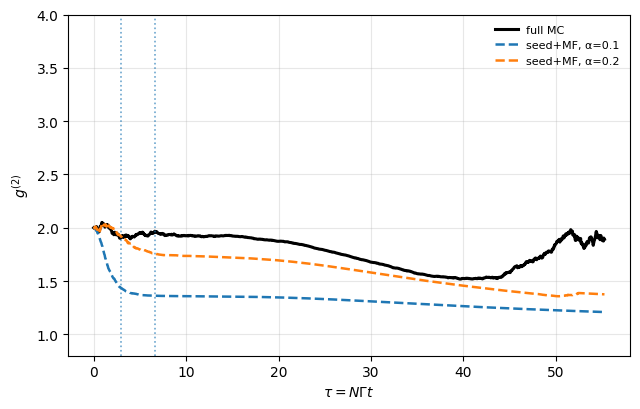

: 

In [ ]:
using PyPlot

j = findfirst(==(2), data.orders)
idx1 = findfirst(==(1), data.orders)

figure(figsize = (6.5, 4.2))

curve0 = data.curves[1]
full_I = curve0.full_G[:, idx1] ./ data.N^2
mask_full = isfinite.(curve0.full_g[:, j]) .& (full_I .> 1 / data.N^2)

plot(curve0.tau[mask_full],
     curve0.full_g[mask_full, j],
     color = "black",
     lw = 2.2,
     label = "full MC")

for curve in data.curves
    seed_I = curve.seed_G1_powers[:, idx1] ./ data.N^2
    mask_seed = isfinite.(curve.seed_g_proxy[:, j]) .& (seed_I .> 1 / data.N^2)

    plot(curve.tau[mask_seed],
         curve.seed_g_proxy[mask_seed, j],
         "--",
         lw = 1.8,
         label = "seed+MF, α=$(curve.c)")

    axvline(curve.seed_summary.tau0_mean,
            ls = ":",
            lw = 1.2,
            alpha = 0.65)
end

xlabel(L"\tau = N \Gamma t")
ylabel(L"g^{(2)}")

ylim(0.8, 4)
legend(frameon = false, fontsize = 8)
grid(true, alpha = 0.3)
tight_layout()

In [35]:

N = 1000000
for curve in data.curves
    res =map(x->x.M, curve.seeds)
    @show mean(res / N)
    res =map(x->x.S, curve.seeds)
    @show mean(res / N)
    println("=====")
end

mean(res / N) = 0.5
mean(res / N) = 0.5
=====
mean(res / N) = 0.47776189950000003
mean(res / N) = 0.4777638995
=====
mean(res / N) = 0.45808312700000003
mean(res / N) = 0.458088229
=====
mean(res / N) = 0.38802516249999996
mean(res / N) = 0.38806219599999997
=====


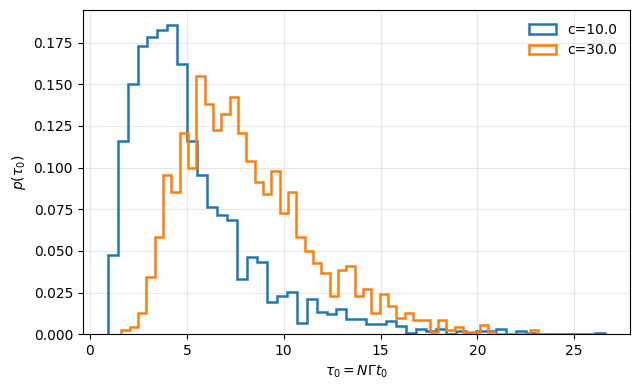

In [4]:
using PyPlot
using Statistics

figure(figsize = (6.5, 4.0))

for curve in data.curves[4:5]
    τ0 = [data.N * data.Gamma * seed.t for seed in curve.seeds if seed.reached]

    bins = 50

    hist(τ0;
         bins = bins,
         density = true,
         histtype = "step",
         lw = 1.8,
         label = "c=$(curve.c)")
end

xlabel(L"\tau_0 = N \Gamma t_0")
ylabel(L"p(\tau_0)")

legend(frameon = false)
grid(true, alpha = 0.3)
tight_layout()


scan 1/80: g_xi = 0, g_gamma = 0
Full jump MC reference: N = 10000, g_xi = 0, gamma = 0, trajectories = 2000
  full MC: 200/2000 trajectories
  full MC: 400/2000 trajectories
  full MC: 600/2000 trajectories
  full MC: 800/2000 trajectories
  full MC: 1000/2000 trajectories
  full MC: 1200/2000 trajectories
  full MC: 1400/2000 trajectories
  full MC: 1600/2000 trajectories
  full MC: 1800/2000 trajectories
  full MC: 2000/2000 trajectories

Seed threshold c = 3
  seed MC c = 3: 30/300 trajectories
  seed MC c = 3: 60/300 trajectories
  seed MC c = 3: 90/300 trajectories
  seed MC c = 3: 120/300 trajectories
  seed MC c = 3: 150/300 trajectories
  seed MC c = 3: 180/300 trajectories
  seed MC c = 3: 210/300 trajectories
  seed MC c = 3: 240/300 trajectories
  seed MC c = 3: 270/300 trajectories
  seed MC c = 3: 300/300 trajectories
  reached 100.0%, tau0 mean 1.816, tau peak full 9.511, seed 9.364, peak I full 0.1973, seed 0.2015

Saved data: /Users/nicobassler/MyDocuments/_RESEARCH/!

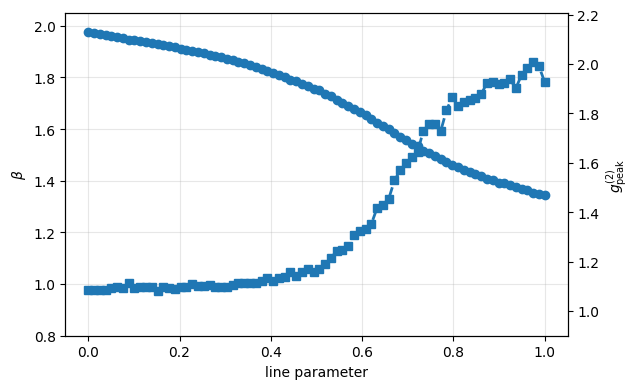

Saved plot: /Users/nicobassler/MyDocuments/_RESEARCH/![R][0_ACTIVE][2025]HTC-dicke-dephasing/data/seed_time_mf/seed_time_mf_c3.pdf


In [102]:
function scan_full_mc_peak_g2_line(;
    N = 5000,
    Gamma = 1.0,
    g_xi_end = 0.4,
    g_gamma_end = 0.4,
    npoints = 15,
    n_full = 300,
    nt = 1500,
    t_fac = 12.0,
    seed = 4321,
)
    xs = collect(range(0.0, 1.0, length = npoints))
    out = Any[]

    for (i, x) in enumerate(xs)
        g_xi = x * g_xi_end
        g_gamma = x * g_gamma_end

        @printf("\nscan %d/%d: g_xi = %.4g, g_gamma = %.4g\n",
                i, length(xs), g_xi, g_gamma)

        data_x = compare_seed_time_mf_trajectories(
            N = N,
            Gamma = Gamma,
            g_xi = g_xi,
            g_gamma = g_gamma,

            c_values = [3.0],   # dummy, only used to expose full_G through curves[1]
            n_full = n_full,
            n_seed = 300,         # dummy
            orders = [1, 2],

            nt = nt,
            t_fac = t_fac,
            seed = seed + i,
            store_full_histories = false,
        )

        curve = data_x.curves[1]

        idx1 = findfirst(==(1), data_x.orders)
        idx2 = findfirst(==(2), data_x.orders)

        G1 = curve.full_G[:, idx1]
        G2 = curve.full_G[:, idx2]

        I = G1 ./ N^2
        kpeak = argmax(I)

        push!(out, (
            x = x,
            g_xi = g_xi,
            g_gamma = g_gamma,
            Ipeak = I[kpeak],
            tau_peak = data_x.tau[kpeak],
            g2_peak = G2[kpeak] / G1[kpeak]^2,
            beta = beta = 2 + log(4 * I[kpeak]) / log(N), #2 + log(I[kpeak]) / log(N),
            data = data_x,
        ))
    end

    return out
end

using PyPlot

    scan = scan_full_mc_peak_g2_line(
        N = 10000,
        g_xi_end = 0.8,
        g_gamma_end = 0.2,
        npoints = 80,
        n_full = 2000,
    )

    x = [r.x for r in scan]
    β = [r.beta for r in scan]
    g2 = [r.g2_peak for r in scan]

    fig, ax1 = subplots(figsize = (6.5, 4.0))

    ax1.plot(x, β, "o-", lw = 2)
    ax1.set_xlabel("line parameter")
    ax1.set_ylabel(L"\beta")
    ax1.set_ylim(0.8, 2.05)
    ax1.grid(true, alpha = 0.3)

    ax2 = ax1.twinx()
    ax2.plot(x, g2, "s--", lw = 2)
    ax2.set_ylabel(L"g^{(2)}_{\mathrm{peak}}")
    ax2.set_ylim(0.9, max(2.1, 1.1 * maximum(g2)))

    fig.tight_layout()


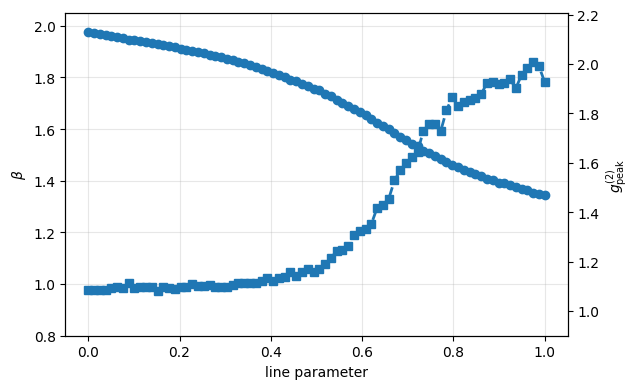

In [107]:
    x = [r.x for r in scan]
    β = [r.beta for r in scan]
    g2 = [r.g2_peak for r in scan]

    fig, ax1 = subplots(figsize = (6.5, 4.0))

    ax1.plot(x, β, "o-", lw = 2)
    ax1.set_xlabel("line parameter")
    ax1.set_ylabel(L"\beta")
    ax1.set_ylim(0.8, 2.05)
    ax1.grid(true, alpha = 0.3)

    ax2 = ax1.twinx()
    ax2.plot(x, g2, "s--", lw = 2)
    ax2.set_ylabel(L"g^{(2)}_{\mathrm{peak}}")
    ax2.set_ylim(0.9, max(2.1, 1.1 * maximum(g2)))

    fig.tight_layout()


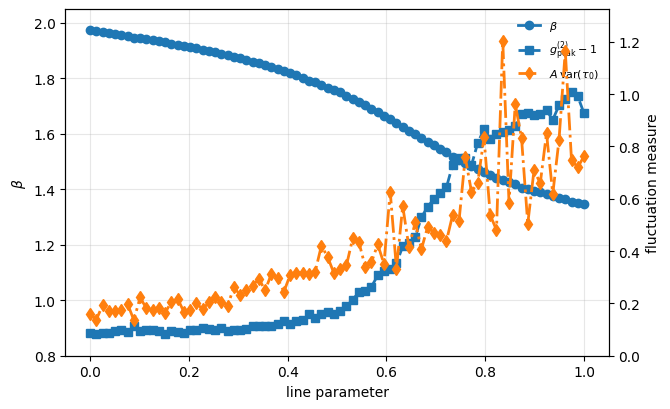

In [120]:
function tau0_values_from_result(r)
    curve = r.data.curves[1]
    return [r.data.N * r.data.Gamma * seed.t for seed in curve.seeds if seed.reached]
end

x = [r.x for r in scan]
β = [r.beta for r in scan]
g2 = [r.g2_peak for r in scan]
#g2 = map(r-> π / sqrt(6.0) / (1.0 - r.g_xi + r.g_gamma), scan).^2

τ0s = [tau0_values_from_result(r) for r in scan]

τ0_mean = [mean(v) for v in τ0s]
τ0_std = [std(v) for v in τ0s]
τ0_var = τ0_std .^ 2
τ0_width90 = [quantile(v, 0.9) - quantile(v, 0.1) for v in τ0s]

y_g2 = g2 .- 1
y_width = τ0_var

A = sum(y_g2 .* y_width) / sum(y_width .^ 2)
g2_width_est = A .* y_width

fig, ax1 = subplots(figsize = (6.8, 4.2))

ax1.plot(x, β, "o-", lw = 2, label = L"\beta")
ax1.set_xlabel("line parameter")
ax1.set_ylabel(L"\beta")
ax1.set_ylim(0.8, 2.05)
ax1.grid(true, alpha = 0.3)

ax2 = ax1.twinx()
ax2.plot(x, y_g2, "s--", lw = 2,
         label = L"g^{(2)}_{\mathrm{peak}}-1")
ax2.plot(x, g2_width_est, "d-.", lw = 2,
         label = L"A\,\mathrm{var}(\tau_0)")

ax2.set_ylabel("fluctuation measure")
ax2.set_ylim(0.0, 1.1 * maximum(vcat(y_g2, g2_width_est)))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(vcat(lines1, lines2), vcat(labels1, labels2),
           frameon = false, fontsize = 8, loc = "best")

fig.tight_layout()

In [ ]:
function tau0_values_from_result(r)
    curve = r.data.curves[1]
    return [r.data.N * r.data.Gamma * seed.t for seed in curve.seeds if seed.reached]
end

function interp_linear(xgrid, ygrid, x)
    if x < first(xgrid) || x > last(xgrid)
        return 0.0
    end

    k = searchsortedlast(xgrid, x)

    if k <= 0
        return first(ygrid)
    elseif k >= length(xgrid)
        return last(ygrid)
    end

    x1, x2 = xgrid[k], xgrid[k + 1]
    y1, y2 = ygrid[k], ygrid[k + 1]

    return y1 + (y2 - y1) * (x - x1) / (x2 - x1)
end

function shifted_g2_peak(τgrid, Igrid, τ0s)
    Iavg = similar(τgrid)
    I2avg = similar(τgrid)

    for (i, τ) in pairs(τgrid)
        vals = [interp_linear(τgrid, Igrid, τ - τ0) for τ0 in τ0s]
        Iavg[i] = mean(vals)
        I2avg[i] = mean(vals .^ 2)
    end

    g2shift = I2avg ./ Iavg .^ 2

    # avoid nonsense from zero-intensity regions
    g2shift[Iavg .<= 0] .= NaN

    ipeak = argmax(Iavg)

    return (
        τ_peak = τgrid[ipeak],
        I_peak = Iavg[ipeak],
        g2_peak = g2shift[ipeak],
        Iavg = Iavg,
        I2avg = I2avg,
        g2 = g2shift,
    )
end



LoadError: Replace mf_tau_I_from_result(r) by the actual MF fields in r.

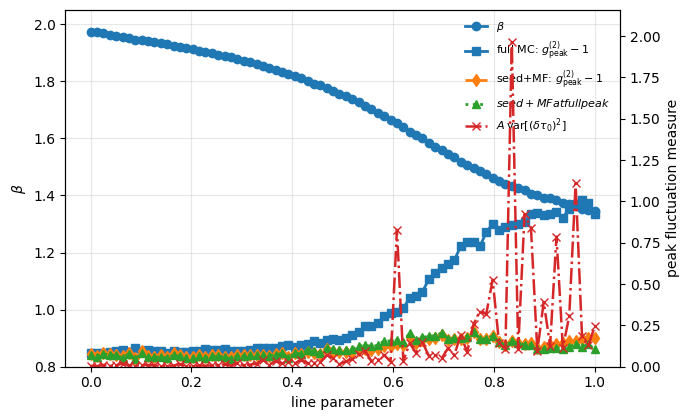

In [145]:
using Statistics
using PyPlot

icurve = 1  # choose cutoff curve, e.g. 1 corresponds to data.curves[1]

x = [r.x for r in scan]
β = [r.beta for r in scan]

idx1 = findfirst(==(1), scan[1].data.orders)
idx2 = findfirst(==(2), scan[1].data.orders)
idx1 === nothing && error("orders must contain 1")
idx2 === nothing && error("orders must contain 2")

g2_full_peak = Float64[]
g2_seed_peak = Float64[]
g2_seed_at_full_peak = Float64[]

I_full_peak = Float64[]
I_seed_peak = Float64[]

tau0_std = Float64[]
tau0_var2 = Float64[]

for r in scan
    data = r.data
    curve = data.curves[icurve]

    full_I = curve.full_G[:, idx1] ./ data.N^2
    seed_I = curve.seed_G1_powers[:, idx1] ./ data.N^2

    i_full_peak = argmax(full_I)
    i_seed_peak = argmax(seed_I)

    push!(g2_full_peak, curve.full_g[i_full_peak, idx2])
    push!(g2_seed_peak, curve.seed_g_proxy[i_seed_peak, idx2])
    push!(g2_seed_at_full_peak, curve.seed_g_proxy[i_full_peak, idx2])

    push!(I_full_peak, full_I[i_full_peak])
    push!(I_seed_peak, seed_I[i_seed_peak])

    tau0 = [data.N * data.Gamma * seed.t for seed in curve.seeds if seed.reached]
    if length(tau0) > 1
        δ = tau0 .- mean(tau0)
        push!(tau0_std, std(tau0))
        push!(tau0_var2, mean(δ .^ 4) - mean(δ .^ 2)^2)
    else
        push!(tau0_std, NaN)
        push!(tau0_var2, NaN)
    end
end

y_full = g2_full_peak .- 1
y_seed = g2_seed_peak .- 1
y_seed_full_time = g2_seed_at_full_peak .- 1

mask = isfinite.(y_full) .& isfinite.(tau0_var2) .& (tau0_var2 .> 0)
A4 = sum(y_full[mask] .* tau0_var2[mask]) / sum(tau0_var2[mask] .^ 2)
y_width4 = A4 .* tau0_var2

fig, ax1 = subplots(figsize = (7.0, 4.3))

ax1.plot(x, β, "o-", lw = 2, label = L"\beta")
ax1.set_xlabel("line parameter")
ax1.set_ylabel(L"\beta")
ax1.set_ylim(0.8, 2.05)
ax1.grid(true, alpha = 0.3)

ax2 = ax1.twinx()
ax2.plot(x, y_full, "s-", lw = 2,
         label = L"full MC: $g^{(2)}_{\mathrm{peak}}-1$")
ax2.plot(x, y_seed, "d--", lw = 2,
         label = L"seed+MF: $g^{(2)}_{\mathrm{peak}}-1$")
ax2.plot(x, y_seed_full_time, "^:", lw = 2,
         label = L"seed+MF at full peak")
ax2.plot(x, y_width4, "x-.", lw = 1.8,
         label = L"A\,\mathrm{var}[(\delta\tau_0)^2]")

ax2.set_ylabel("peak fluctuation measure")
ymax = 1.1 * maximum(filter(isfinite, vcat(y_full, y_seed, y_seed_full_time, y_width4)))
ax2.set_ylim(0.0, ymax)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(vcat(lines1, lines2), vcat(labels1, labels2),
           frameon = false, fontsize = 8, loc = "best")

fig.tight_layout()

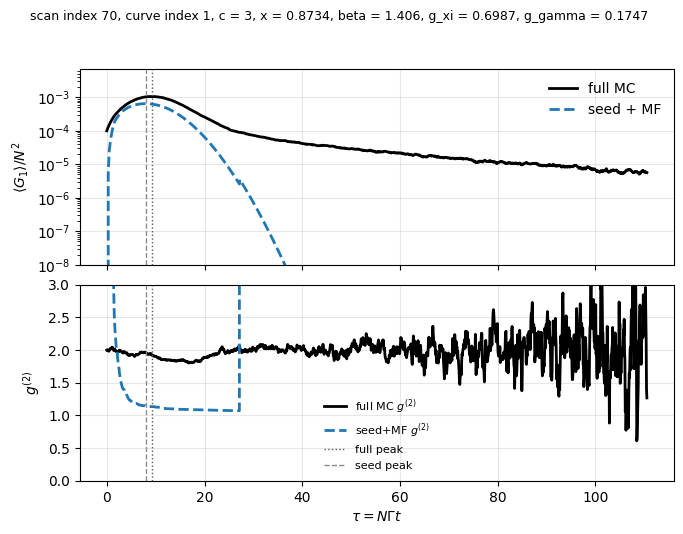

(Figure(PyObject <Figure size 700x540 with 2 Axes>), PyCall.PyObject[PyObject <Axes: ylabel='$\\langle G_1\\rangle/N^2$'>, PyObject <Axes: xlabel='$\\tau=N\\Gamma t$', ylabel='$g^{(2)}$'>])

In [164]:
using PyPlot
using Statistics

function plot_representative_time_traces(scan; iscan = 1, icurve = 1, outfile = nothing)
    r = scan[iscan]
    data = r.data
    curve = data.curves[icurve]

    idx1 = findfirst(==(1), data.orders)
    idx2 = findfirst(==(2), data.orders)
    idx1 === nothing && error("orders must contain 1")
    idx2 === nothing && error("orders must contain 2")

    tau = curve.tau

    full_I = curve.full_G[:, idx1] ./ data.N^2
    seed_I = curve.seed_G1_powers[:, idx1] ./ data.N^2

    full_g2 = curve.full_g[:, idx2]
    seed_g2 = curve.seed_g_proxy[:, idx2]

    i_full_peak = argmax(full_I)
    i_seed_peak = argmax(seed_I)

    fig, axes = subplots(2, 1, figsize = (7.0, 5.4), sharex = true)

    axes[1].plot(tau, full_I, "k-", lw = 2.0, label = "full MC")
    axes[1].plot(tau, seed_I, "--", lw = 2.0, label = "seed + MF")
    axes[1].axvline(tau[i_full_peak], color = "0.35", lw = 1.0, ls = ":")
    axes[1].axvline(tau[i_seed_peak], color = "0.55", lw = 1.0, ls = "--")
    axes[1].set_ylabel(L"\langle G_1\rangle/N^2")
    axes[1].set_yscale("log")
    axes[1].grid(true, alpha = 0.3)
    axes[1].legend(frameon = false)

    full_mask = isfinite.(full_g2) .& (full_I .> data.plot_I_min)
    seed_mask = isfinite.(seed_g2) .& (seed_I .> data.plot_I_min)

    axes[2].plot(tau[full_mask], full_g2[full_mask], "k-", lw = 2.0,
                 label = L"full MC $g^{(2)}$")
    axes[2].plot(tau[seed_mask], seed_g2[seed_mask], "--", lw = 2.0,
                 label = L"seed+MF $g^{(2)}$")
    axes[2].axvline(tau[i_full_peak], color = "0.35", lw = 1.0, ls = ":",
                    label = "full peak")
    axes[2].axvline(tau[i_seed_peak], color = "0.55", lw = 1.0, ls = "--",
                    label = "seed peak")
    axes[2].set_xlabel(L"\tau=N\Gamma t")
    axes[2].set_ylabel(L"g^{(2)}")
    axes[2].grid(true, alpha = 0.3)
    axes[2].legend(frameon = false, fontsize = 8)

    title = @sprintf(
        "scan index %d, curve index %d, c = %.4g, x = %.4g, beta = %.4g, g_xi = %.4g, g_gamma = %.4g",
        iscan,
        icurve,
        curve.c,
        r.x,
        r.beta,
        r.g_xi,
        r.g_gamma,
    )
    fig.suptitle(title, fontsize = 9)
    fig.tight_layout(rect = [0, 0, 1, 0.95])

    if outfile !== nothing
        mkpath(dirname(outfile))
        fig.savefig(outfile, bbox_inches = "tight")
    end

    axes[2].set_ylim(bottom = 0.0, top = 3.0)
    axes[1].set_ylim(bottom = 1e-8)

    return fig, axes
end

# Example:
fig, axes = plot_representative_time_traces(scan; iscan = 70, icurve = 1)

# Or save:
# plot_representative_time_traces(scan; iscan = 10, icurve = 1,
#     outfile = "../data/representative_seed_mf_trace.pdf")

In [38]:
function tau0_values_from_result(r)
    curve = r.data.curves[1]
    return [r.data.N * r.data.Gamma * seed.t for seed in curve.seeds if seed.reached]
end

x = [r.x for r in scan]

τ0s = [tau0_values_from_result(r) for r in scan]

τ0_mean = [mean(v) for v in τ0s]
τ0_std = [std(v) for v in τ0s]
τ0_cv = τ0_std #./ τ0_mean
τ0_width90 = [quantile(v, 0.9) - quantile(v, 0.1) for v in τ0s]

plot(x, τ0_cv, "d-.", lw = 2, label = L"\mathrm{std}(\tau_0)")
plot(x, map(r-> π / sqrt(6.0) / (1.0 - r.g_xi + r.g_gamma), scan))

LoadError: UndefVarError: `scan` not defined in `Main`
Suggestion: check for spelling errors or missing imports.